In [ ]:
# ! pip install pyarrow

In [1]:
from IPython.display import HTML, display

html_code = """
<div style="display: flex; align-items: center; justify-content: center; gap: 30px; padding: 40px; background-color: #f8f9fa; border-radius: 15px; border-left: 8px solid #e3000f; box-shadow: 0 6px 12px rgba(0,0,0,0.08); margin-bottom: 30px;">
    
    <!-- Logo maior (dobro do anterior) -->
    <img src="https://logodownload.org/wp-content/uploads/2014/02/claro-logo-8.png" alt="Claro" style="height: 90px; object-fit: contain;">
    
    <!-- Sinal de '+' mais espesso e maior -->
    <div style="font-size: 55px; font-weight: bold; color: #e3000f; animation: pulse 2s infinite;">+</div>
    
    <!-- Emoji/IA bem maior -->
    <div style="font-size: 90px; animation: float 3s ease-in-out infinite;">🤖</div>
    
    <!-- Textos redimensionados -->
    <div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin-left: 20px;">
        <h2 style="margin: 0; color: #333; font-size: 42px; font-weight: 800; letter-spacing: -1px;">Case de Retenção</h2>
        <p style="margin: 5px 0 0 0; color: #666; font-size: 24px; font-weight: 600; text-transform: uppercase; letter-spacing: 1px;">AI & Predictive Analytics</p>
    </div>
</div>

<style>
    @keyframes pulse {
        0% { transform: scale(1); opacity: 1; }
        50% { transform: scale(1.2); opacity: 0.6; }
        100% { transform: scale(1); opacity: 1; }
    }
    @keyframes float {
        0% { transform: translateY(0px); }
        50% { transform: translateY(-12px); }
        100% { transform: translateY(0px); }
    }
</style>
"""
display(HTML(html_code))

### Import Libs

In [2]:
## libs diversas para analises
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import json
import os

## libs para modelos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef
from sklearn.model_selection import cross_val_score
from scipy.stats import ks_2samp

# Configuração visual profissional (Padrão Claro)
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "#d3d3d3", "xtick.color": "#333333", "ytick.color": "#333333"})
cores_claro = ['#333333', '#e3000f'] # Preto e Vermelho

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Ler arquivo excel

In [ ]:
# df = pd.read_excel("../data/Cópia de bd_case_final_1.xlsx")

### Converter excel para .parquet (maior velocidade de leitura)

In [ ]:
# Salva em um formato otimizado e ultrarrápido
# df.to_parquet("../data/bd_case_otimizado.parquet")

### Ler arquivo .parquet

In [3]:
# ler arquivo mais rapido
df_fast = pd.read_parquet("../data/bd_case_otimizado.parquet")

In [4]:
df_fast.head()

,id_cliente,DATA_FUNIL_SOLAR,COD_IBGE,DSC_CIDADE,SGL_UF,flag_movel,DSC_CLI_MPLAY_M0,DSC_CLI_MPLAY_M30,NM_SUB_INDICADOR_NEGOCIO,NM_GRUPO_REGIONAL,FLAG_ORIGEM,ID_PRODUTO_BL_M0,DSC_PRODUTO_BL_M0,VALOR_BL_M0,ID_PRODUTO_BL_M30,DSC_PRODUTO_BL_M30,VALOR_BL_M30,ID_PRODUTO_TV_M0,DSC_PRODUTO_TV_M0,VALOR_TV_M0,ID_PRODUTO_TV_M30,DSC_PRODUTO_TV_M30,VALOR_TV_M30,ID_PRODUTO_FONE_M0,DSC_PRODUTO_FONE_M0,VALOR_FONE_M0,ID_PRODUTO_FONE_M30,DSC_PRODUTO_FONE_M30,VALOR_FONE_M30,COD_PLANO_MOVEL_M0,DSC_PLANO_MOVEL_M0,VALOR_MV_M0,COD_PLANO_MOVEL_M30,DSC_PLANO_MOVEL_M30,VALOR_MV_M30,FLAG_MOV_BL,FLAG_MOV_TV,FLAG_MOV_FONE,FLAG_MOV_MV,FLAG_CANC_BL,FLAG_CANC_TV,FLAG_CANC_FONE,FLAG_CANC_MV,MEIO_FISICO_BROWNFIELD,FLG_BROWNFIELD,TP_REDE_HP,GRUPO_DA_TABELA_DE_PRECOS,CLASSIFICACAO
0,000007b110f70f4ab0ae4d0fd1342d5df26edb6477c6ce241c928a64d7a5f06f,2025-07-21 14:19:00,3550308,SAO PAULO,SP,0,NaN,NaN,NAO RETIDO,GRUPO SP CAPITAL,SOLAR,58524,BL 300M MIGRACAO FID,98.8,0,NaN,0.0,0,NaN,0.00,0,NaN,0.00,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,0,0,0,1,0,0,0,NaN,0,HFC,PADRÃO,G1
1,000010c5d956f0f878f173ee8b6727584fd371e2c4b0355c3a0ae7230cf79500,2025-06-10 13:34:00,3304557,RIO DE JANEIRO,RJ,1,NaN,NaN,RETIDO,GRUPO RIO E ES,SOLAR,58436,BL 750M GPLAY COMB ATQ EXC REV PON FID,104.9,58436,BL 750M GPLAY COMB ATQ EXC REV PON FID,104.9,59142,CTV+ STREAMING HD TOP 3P/4P ANUNCIO FID,104.90,0,NaN,0.00,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,0,0,0,0,1,0,0,GPON,1,GPON,PADRÃO,G1
2,00006142455cc2589fc917e1e9d22ffdb11b0d114fe343d31658d4cc6e07dbcc,2025-09-01 18:00:00,3550308,SAO PAULO,SP,0,NaN,NaN,RETIDO,GRUPO SP CAPITAL,SOLAR,59641,BANDA LARGA 600M GPLAY MIG PREV FID,114.9,59996,BL MULTI TURB 600M GPLAY FID,99.9,57891,CLARO STREAMING HD TVMAIS TOP SOLAR FID,104.30,58866,CLARO STREAMING HD TOP GPLAY RET FID,74.90,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,1,1,0,0,0,0,0,0,NaN,0,HFC,PADRÃO,G1
3,0000d0c2d83299e77b6f237bb206645a09e1ed143763396f1ffe1f5399dc2778,2025-12-04 20:09:00,3543402,RIBEIRAO PRETO,SP,1,NaN,NaN,RETIDO,GRUPO SP INTERIOR,SOLAR,59641,BANDA LARGA 600M GPLAY MIG PREV FID,119.9,59641,BANDA LARGA 600M GPLAY MIG PREV FID,124.9,0,NaN,0.00,0,NaN,0.00,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,0,0,0,0,0,0,0,NaN,0,HFC,ESPECIAL,G2
4,0000d37fc6b8e8188a0b59b043485292574c5585480503cbe6ea06f63d798d66,2025-06-25 17:57:00,3534401,OSASCO,SP,0,NaN,NaN,RETIDO,GRUPO SP CAPITAL,LEGADO,58524,BL 300M MIGRACAO FID,98.8,58524,BL 300M MIGRACAO FID,98.8,52697,NET MIX HD C/VTA PAD EXC RET FID,245.36,52697,NET MIX HD C/VTA PAD EXC RET FID,245.36,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,0,0,0,0,0,0,0,NaN,0,HFC,PADRÃO,G1


## Features Engineer / Tratamento de dados

In [5]:
# 1. Padronizar nomes das colunas para minúsculo
df_fast.columns = [col.lower() for col in df_fast.columns]

# 2. Tratamento de Nulos com base na regra de negócio
colunas_mplay = ['dsc_cli_mplay_m0', 'dsc_cli_mplay_m30']
for col in colunas_mplay:
    if col in df_fast.columns:
        df_fast[col] = df_fast[col].fillna('Nao_Elegivel')

# 3. Engenharia de Features Temporais
# Transformar a string de data em formato datetime e extrair informações úteis
df_fast['data_funil_solar'] = pd.to_datetime(df_fast['data_funil_solar'])
df_fast['mes_entrada'] = df_fast['data_funil_solar'].dt.month
df_fast['dia_semana_entrada'] = df_fast['data_funil_solar'].dt.dayofweek

In [6]:
# visualizar dados tratados
df_fast[['id_cliente','dsc_cli_mplay_m0','dsc_cli_mplay_m30','data_funil_solar','data_funil_solar','mes_entrada','dia_semana_entrada']].head(10)

,id_cliente,dsc_cli_mplay_m0,dsc_cli_mplay_m30,data_funil_solar,data_funil_solar,mes_entrada,dia_semana_entrada
0,000007b110f70f4ab0ae4d0fd1342d5df26edb6477c6ce241c928a64d7a5f06f,Nao_Elegivel,Nao_Elegivel,2025-07-21 14:19:00,2025-07-21 14:19:00,7,0
1,000010c5d956f0f878f173ee8b6727584fd371e2c4b0355c3a0ae7230cf79500,Nao_Elegivel,Nao_Elegivel,2025-06-10 13:34:00,2025-06-10 13:34:00,6,1
2,00006142455cc2589fc917e1e9d22ffdb11b0d114fe343d31658d4cc6e07dbcc,Nao_Elegivel,Nao_Elegivel,2025-09-01 18:00:00,2025-09-01 18:00:00,9,0
3,0000d0c2d83299e77b6f237bb206645a09e1ed143763396f1ffe1f5399dc2778,Nao_Elegivel,Nao_Elegivel,2025-12-04 20:09:00,2025-12-04 20:09:00,12,3
4,0000d37fc6b8e8188a0b59b043485292574c5585480503cbe6ea06f63d798d66,Nao_Elegivel,Nao_Elegivel,2025-06-25 17:57:00,2025-06-25 17:57:00,6,2
5,0000e108949cd4fcc51abdc6a7b19f5cbb1ded4cd198fc5be5b908b90dc2cb23,Nao_Elegivel,Nao_Elegivel,2025-11-10 10:40:00,2025-11-10 10:40:00,11,0
6,000101c115566f66d759bf9ec8086207582195f773c3c93d1c0146464c352ab5,Nao_Elegivel,Nao_Elegivel,2025-10-09 18:40:00,2025-10-09 18:40:00,10,3
7,000101c115566f66d759bf9ec8086207582195f773c3c93d1c0146464c352ab5,Nao_Elegivel,Nao_Elegivel,2025-10-10 06:28:00,2025-10-10 06:28:00,10,4
8,000238314f959b5a4a261aeea3804d7218a20142aab355b4068aaf59bd7e54e4,Nao_Elegivel,Nao_Elegivel,2025-07-02 17:07:00,2025-07-02 17:07:00,7,2
9,00024e14b62356dce2501f911549fb90bb6a32ead0872791ab2b77e12f298853,Nao_Elegivel,Nao_Elegivel,2025-07-08 17:59:00,2025-07-08 17:59:00,7,1


In [7]:
# visualizar dados tratados (de baixo para cima)
df_fast[['id_cliente','dsc_cli_mplay_m0','dsc_cli_mplay_m30','data_funil_solar','data_funil_solar','mes_entrada','dia_semana_entrada']].tail(10)

,id_cliente,dsc_cli_mplay_m0,dsc_cli_mplay_m30,data_funil_solar,data_funil_solar,mes_entrada,dia_semana_entrada
303644,fffed751ca2ddf893d5d4960925d3da8c928d31386cd38f4778ec4b1781aa0ef,MARCADO,Nao_Elegivel,2025-08-27 11:16:00,2025-08-27 11:16:00,8,2
303645,fffed751ca2ddf893d5d4960925d3da8c928d31386cd38f4778ec4b1781aa0ef,Nao_Elegivel,Nao_Elegivel,2025-11-05 14:21:00,2025-11-05 14:21:00,11,2
303646,ffff350857bb41bfb944596c2eef475f209594ea1f53672f641725eb60da6c4c,Nao_Elegivel,Nao_Elegivel,2025-06-28 23:08:00,2025-06-28 23:08:00,6,5
303647,ffff4f39caf22c0d044f4b5cad163f64bba618b9ca8f1ca00e64e38eef71488a,Nao_Elegivel,Nao_Elegivel,2025-06-12 09:42:00,2025-06-12 09:42:00,6,3
303648,ffff7a69b69ea7f48f8a2c890d0d4546a643d3e3b06b261a442062b76454de78,Nao_Elegivel,Nao_Elegivel,2025-08-28 15:47:00,2025-08-28 15:47:00,8,3
303649,ffff8d429a5aed30a6730b9255a04061142704d2bd137a10295c7f725909672c,NAO-MARCADO,Nao_Elegivel,2025-08-12 18:24:00,2025-08-12 18:24:00,8,1
303650,ffffb2bdda053f00bf6e8c121019c910384a7420f2422dcd05d8ac98bacf44ac,Nao_Elegivel,Nao_Elegivel,2025-07-28 19:46:00,2025-07-28 19:46:00,7,0
303651,ffffb2bdda053f00bf6e8c121019c910384a7420f2422dcd05d8ac98bacf44ac,Nao_Elegivel,Nao_Elegivel,2025-07-30 17:37:00,2025-07-30 17:37:00,7,2
303652,ffffb2bdda053f00bf6e8c121019c910384a7420f2422dcd05d8ac98bacf44ac,Nao_Elegivel,Nao_Elegivel,2025-09-03 15:24:00,2025-09-03 15:24:00,9,2
303653,ffffe324e4b5370db7e53308b588bca1cae30d4bab2794cde386cbfd1d020de7,Nao_Elegivel,Nao_Elegivel,2025-12-03 13:26:00,2025-12-03 13:26:00,12,2


In [8]:
# 4. Definição da Variável Alvo (Target)
# Identificar perfis de clientes RETIDOS e COM MOVIMENTAÇÃO.
# Criar uma coluna 'target' onde 1 = (Retido E flag_mov == 1), e 0 = Demais casos.
if 'flag_mov' in df_fast.columns and 'nm_sub_indicador_negocio' in df_fast.columns:
    df_fast['target'] = np.where(
        (df_fast['nm_sub_indicador_negocio'] == 'RETIDO') & (df_fast['flag_mov'] == 1), 
        1, 
        0
    )
    print(f"Distribuição do Target:\n{df_fast['target'].value_counts(normalize=True) * 100}")

# 5. Visão geral para checar o que mais precisa de tratamento
print("\n--- Validação de Nulos Restantes ---")
display(df_fast.isnull().sum()[df_fast.isnull().sum() > 0])


--- Validação de Nulos Restantes ---


dsc_produto_bl_m0          13731
dsc_produto_bl_m30         70209
dsc_produto_tv_m0         148335
dsc_produto_tv_m30        178403
dsc_produto_fone_m0       204296
dsc_produto_fone_m30      230981
dsc_plano_movel_m0        291022
dsc_plano_movel_m30       291022
meio_fisico_brownfield    241974
dtype: int64

* Obs: No display acima, mostra que existem muitos nulos além do target não ter sido criado corretamente, para contornar isso é necessário fazer mais um passo das features engineer

In [9]:
# 1. Tratamento dos Nulos de Produtos (Transformar NaN em 'Sem_Produto')
colunas_produtos = [col for col in df_fast.columns if 'dsc_produto' in col or 'dsc_plano' in col]
for col in colunas_produtos:
    df_fast[col] = df_fast[col].fillna('Sem_Produto')

if 'meio_fisico_brownfield' in df_fast.columns:
    df_fast['meio_fisico_brownfield'] = df_fast['meio_fisico_brownfield'].fillna('Nao_Informado')

# 2. Criar a Flag Geral de Movimentação
# Pega todas as colunas que começam com 'flag_mov_' (excluindo a flag_movel que é posse de aparelho)
colunas_movimentacao = [col for col in df_fast.columns if col.startswith('flag_mov_')]

# Se ele movimentou QUALQUER produto, a soma será > 0, então a flag geral recebe 1
if len(colunas_movimentacao) > 0:
    df_fast['flag_mov_geral'] = np.where(df_fast[colunas_movimentacao].sum(axis=1) > 0, 1, 0)
else:
    # Caso a coluna se chame apenas 'flag_mov' e tenha passado despercebida
    df_fast['flag_mov_geral'] = df_fast.get('flag_mov', 0)

# 3. Criar o Target (Agora vai funcionar!)
df_fast['target'] = np.where(
    (df_fast['nm_sub_indicador_negocio'] == 'RETIDO') & (df_fast['flag_mov_geral'] == 1), 
    1, 
    0
)

print("--- Base Limpa! ---")
print(f"Distribuição do Target:\n{df_fast['target'].value_counts(normalize=True) * 100}")
print("\nVerificando se sobrou algum Nulo:")
display(df_fast.isnull().sum()[df_fast.isnull().sum() > 0])

--- Base Limpa! ---
Distribuição do Target:
target
0    71.500458
1    28.499542
Name: proportion, dtype: float64

Verificando se sobrou algum Nulo:


Series([], dtype: int64)

## Análise Exploratória (EDA)

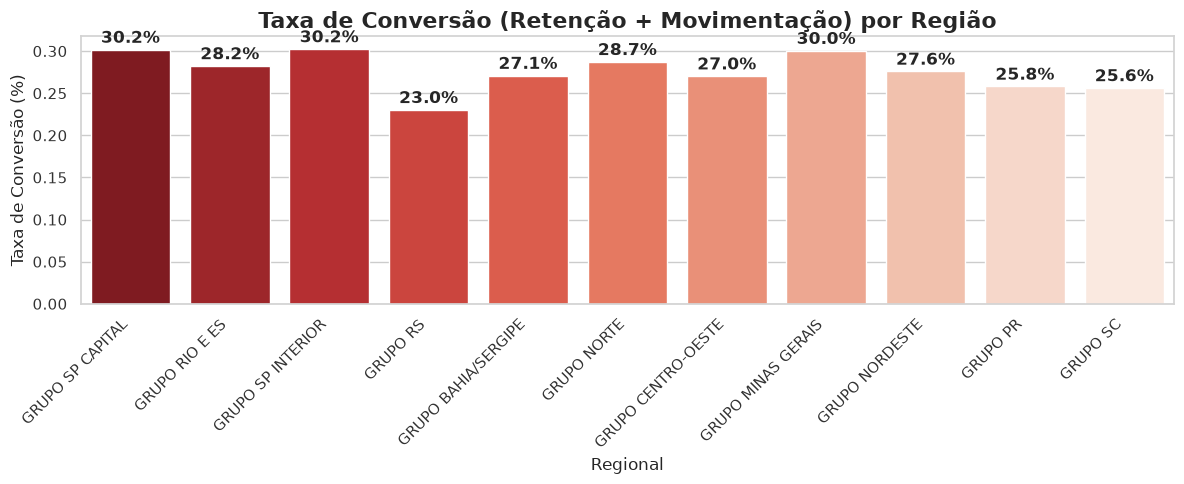

In [10]:
# Gráfico: Qual a taxa de sucesso (Target=1) por Região?
plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=df_fast,
    x='nm_grupo_regional', 
    y='target', 
    errorbar=None, 
    palette="Reds_r",
    hue='nm_grupo_regional',
    legend=False
)
plt.title('Taxa de Conversão (Retenção + Movimentação) por Região', fontsize=16, fontweight='bold')
plt.ylabel('Taxa de Conversão (%)')
plt.xlabel('Regional')
plt.xticks(rotation=45, ha='right')

# Adicionando os rótulos de porcentagem em cima das barras
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

💡 **Insights de Negócio**: Conversão por Região. <br> * **Fortalezas da Operação**: As regiões de São Paulo (Capital e Interior) e Minas Gerais lideram a taxa de conversão (atingindo a marca de 30%). Isso sugere uma forte aderência dos clientes dessas praças às ofertas do funil de retenção, o que pode estar atrelado à qualidade da infraestrutura local da Claro ou ao perfil de consumo (maior aceitação de combos). <br>  * **Zona de Risco (Gargalo de Retenção)**: A região Sul (RS com 23.0%, SC com 25.6% e PR com 25.8%) concentra as menores taxas de retenção com movimentação. <br> * **Hipótese Analítica**: O baixo desempenho no Sul pode ser reflexo da alta pulverização de concorrentes locais (provedores regionais de fibra óptica) que oferecem preços agressivos, tornando as ofertas de retenção padrão da Claro menos competitivas nessa região.<br> * **Recomendação Preliminar**: A área de negócios precisa desenhar ofertas de retenção regionalizadas. O que funciona para reter um cliente em São Paulo claramente não tem a mesma eficiência no Rio Grande do Sul.

### Investigação do impacto da ferramenta (Solar vs Legado)

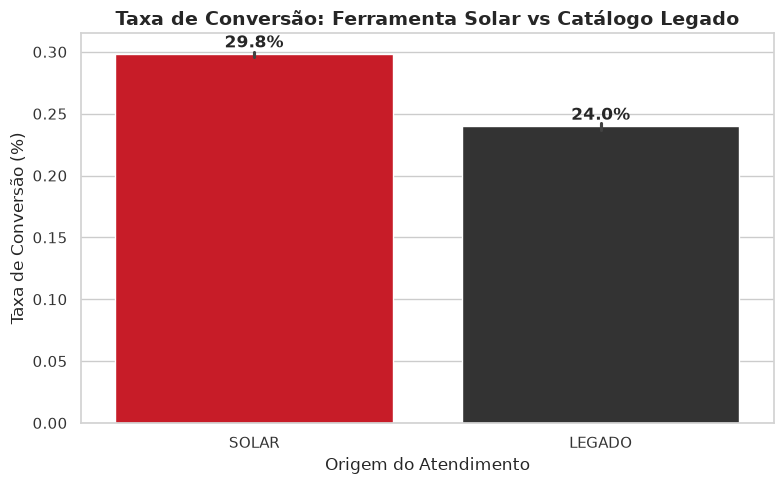

In [11]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_fast, 
    x='flag_origem', 
    y='target', 
    hue='flag_origem',
    legend=False,
    palette=['#e3000f', '#333333'] # Vermelho e Preto
)
plt.title('Taxa de Conversão: Ferramenta Solar vs Catálogo Legado', fontsize=14, fontweight='bold')
plt.ylabel('Taxa de Conversão (%)')
plt.xlabel('Origem do Atendimento')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height()*100:.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

💡 **Insights de Negócio**: Impacto do Motor de Recomendação <br> * **Eficácia Comprovada**: A ferramenta de recomendação "Solar" apresenta uma taxa de conversão (29.8%) visivelmente superior ao uso do catálogo completo "Legado" (24.0%). <br> * **Conclusão Analítica**: O uso de recomendações direcionadas reduz o atrito e é mais assertivo para reter o cliente gerando movimentação do que deixar o operador "pescar" ofertas em um catálogo genérico. <br> * **Recomendação Estratégica**: A diretoria deve investigar por que uma parcela dos atendimentos ainda escoa para o fluxo "Legado". É instabilidade sistêmica? Operadores antigos que resistem à nova ferramenta? A meta operacional deve ser maximizar a adoção da plataforma Solar, pois ela garante maior retenção de receita.

## Separação das Features

In [12]:
# 1. Separar o que é feature (X) e o que é o alvo (y)
colunas_vazamento = [col for col in df_fast.columns if 'flag_mov' in col or 'flag_canc' in col]
# Identificar todas as variáveis do "Futuro" (M30)
colunas_futuro = [col for col in df_fast.columns if '_m30' in col]

colunas_remover = ['id_cliente', 'data_funil_solar', 'nm_sub_indicador_negocio', 'target', 'dsc_cidade', 'cod_ibge'] + colunas_vazamento + colunas_futuro

X = df_fast.drop(columns=colunas_remover, errors='ignore')
y = df_fast['target']

# 2. Investigação e Tratamento de Alta Cardinalidade
cat_cols = X.select_dtypes(include=['object']).columns

print("--- Investigação de Textos ---")
colunas_para_dropar = []

for col in cat_cols:
    valores_unicos = X[col].nunique()
    print(f"Coluna '{col}': {valores_unicos} categorias")
    
    # Se tiver mais de 50 categorias, o get_dummies vai explodir
    if valores_unicos > 50:
        colunas_para_dropar.append(col)

print(f"\n🚨 Removendo por alta cardinalidade: {colunas_para_dropar}")
X = X.drop(columns=colunas_para_dropar, errors='ignore')

# 3. Conversão Segura (Apenas nas colunas sobreviventes)
cat_cols_sobreviventes = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=cat_cols_sobreviventes, drop_first=True)

# 4. Separar base de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

print(f"\n✅ Dimensões FINAIS do Treino: {X_train.shape}")
print(f"✅ Dimensões FINAIS do Teste: {X_test.shape}")

/tmp/ipykernel_157/3508653414.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns
/tmp/ipykernel_157/3508653414.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for 

--- Investigação de Textos ---
Coluna 'sgl_uf': 26 categorias
Coluna 'dsc_cli_mplay_m0': 3 categorias
Coluna 'nm_grupo_regional': 11 categorias
Coluna 'flag_origem': 2 categorias
Coluna 'dsc_produto_bl_m0': 1582 categorias
Coluna 'dsc_produto_tv_m0': 1938 categorias
Coluna 'dsc_produto_fone_m0': 395 categorias
Coluna 'dsc_plano_movel_m0': 262 categorias
Coluna 'meio_fisico_brownfield': 4 categorias
Coluna 'tp_rede_hp': 3 categorias
Coluna 'grupo_da_tabela_de_precos': 11 categorias
Coluna 'classificacao': 13 categorias

🚨 Removendo por alta cardinalidade: ['dsc_produto_bl_m0', 'dsc_produto_tv_m0', 'dsc_produto_fone_m0', 'dsc_plano_movel_m0']

✅ Dimensões FINAIS do Treino: (212557, 76)
✅ Dimensões FINAIS do Teste: (91097, 76)


💡 **Preparação de Dados**: Proteção contra Vazamento e Maldição da Dimensionalidade <br> * Antes de expor os dados ao modelo preditivo, duas intervenções arquiteturais foram necessárias para garantir a integridade do aprendizado: <br> * **Tratamento de Vazamento de Dados (Target Leakage)**: Variáveis que representam o futuro, ou seja, o status do cliente após a interação (_M30), bem como flags explícitas de cancelamento, foram rigorosamente excluídas. Se mantidas, o algoritmo criaria uma dependência artificial ("máquina do tempo"), resultando em métricas de performance ilusórias (overfitting por vazamento) e inviabilizando o uso do modelo no mundo real, onde o operador, no momento M0, desconhece o desfecho do atendimento. <br> * **Controle de Alta Cardinalidade**: Variáveis categóricas com um número excessivo de valores únicos (ex: códigos de IBGE, descrições detalhadas de milhares de produtos legados) foram removidas da matriz de features (X). A aplicação de One-Hot Encoding sobre essas colunas geraria milhares de novas dimensões (Maldição da Dimensionalidade), o que causaria ruído sistêmico, diluiria o peso das variáveis comportamentais críticas e comprometeria severamente a performance e o tempo de treinamento.

## Treinando o Modelo XGBoost

In [13]:
# 1. Configurar o Algoritmo
# Calcula o peso para equilibrar a proporção de 71% (Não retidos) vs 28% (Retidos)
peso_balanceamento = y_train.value_counts()[0] / y_train.value_counts()[1]

modelo_xgb = xgb.XGBClassifier(
    n_estimators=150,           # Quantidade de 'árvores' de decisão
    learning_rate=0.1,          # Velocidade de aprendizado
    max_depth=5,                # Profundidade (evita que o modelo decore regras complexas demais)
    scale_pos_weight=peso_balanceamento, # Força o modelo a dar atenção aos 28% minoritários
    random_state=42,
    n_jobs=-1                   # Usa todos os núcleos do processador para ser mais rápido
)

print("🤖 Treinando o modelo XGBoost (Pode levar alguns segundos/minutos)...")
modelo_xgb.fit(X_train, y_train)

# 2. Fazer Previsões na Base de Teste (Dados invisíveis para o modelo)
y_pred = modelo_xgb.predict(X_test)
y_prob = modelo_xgb.predict_proba(X_test)[:, 1]

# 3. Exibir os Resultados
print("\n--- Relatório de Desempenho ---")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
print(f"\n🎯 AUC-ROC: {auc:.4f}")
print("(Métrica AUC vai de 0.5 a 1.0. Acima de 0.70 indica um modelo com bom poder de separação dos perfis)")

🤖 Treinando o modelo XGBoost (Pode levar alguns segundos/minutos)...

--- Relatório de Desempenho ---
              precision    recall  f1-score   support

           0       0.81      0.63      0.71     65135
           1       0.41      0.63      0.49     25962

    accuracy                           0.63     91097
   macro avg       0.61      0.63      0.60     91097
weighted avg       0.70      0.63      0.65     91097


🎯 AUC-ROC: 0.6878
(Métrica AUC vai de 0.5 a 1.0. Acima de 0.70 indica um modelo com bom poder de separação dos perfis)


🤖 **Modelagem Preditiva: XGBoost e Calibração de Decisão** <br> * Para esta classificação binária, a escolha do XGBoost (Extreme Gradient Boosting) justifica-se por ser o estado da arte na literatura para dados tabulares, lidando nativamente com não-linearidades e relações complexas entre variáveis, sem a necessidade de normalização de escala rigorosa exigida por redes neurais. <br> * **Desafio do Desbalanceamento**: O funil de retenção é naturalmente desbalanceado (apenas ~28% dos clientes da amostra realizam movimentações de interesse). Para evitar que o algoritmo favorecesse a classe majoritária (não retenção), o parâmetro de sensibilidade (scale_pos_weight) foi ajustado proporcionalmente. <br> * **Foco no Recall Estratégico**: A parametrização do algoritmo prioriza a identificação do cliente propenso à movimentação (Recall). No contexto de Telecomunicações, o Custo de Oportunidade (LTV perdido pelo Churn) é substancialmente maior do que o custo marginal de apresentar uma oferta de retenção a um "falso positivo" (cliente que, no fim, não aceitaria a movimentação).

## Validação de Produção

--- TESTES DE ESTRESSE E VALIDAÇÃO PARA PRODUÇÃO ---
1. Realizando Validação Cruzada (K-Fold CV) no Treino...
   -> AUCs em 5 blocos diferentes: [0.6859 0.6887 0.682  0.6882 0.6892]
   -> AUC Médio (Estresse): 0.6868 (+/- 0.0053)
2. Coeficiente de Matthews (MCC): 0.2391
3. Métrica KS (Kolmogorov-Smirnov): 0.2634 (ou 26.3%)
4. Matriz de Confusão:


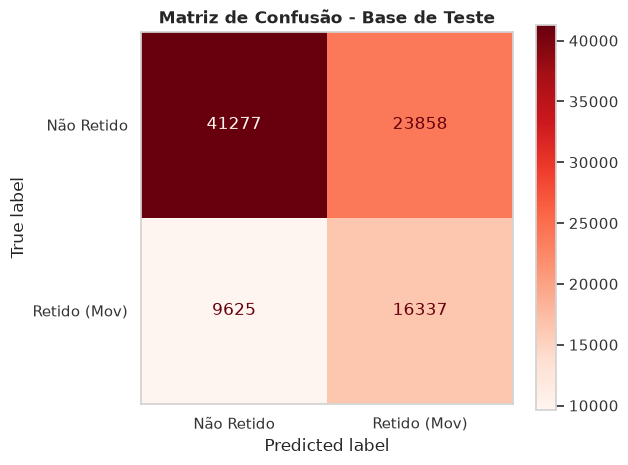

In [14]:
print("--- TESTES DE ESTRESSE E VALIDAÇÃO PARA PRODUÇÃO ---")

# 1. Teste de Overfitting: Validação Cruzada (K-Fold = 5)
print("1. Realizando Validação Cruzada (K-Fold CV) no Treino...")
cv_scores = cross_val_score(modelo_xgb, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"   -> AUCs em 5 blocos diferentes: {np.round(cv_scores, 4)}")
print(f"   -> AUC Médio (Estresse): {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# 2. Coeficiente de Matthews (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"2. Coeficiente de Matthews (MCC): {mcc:.4f}")

# 3. Métrica KS (Kolmogorov-Smirnov)
# Separa as probabilidades de quem é 0 e quem é 1
prob_0 = y_prob[y_test == 0]
prob_1 = y_prob[y_test == 1]
ks_stat, p_value = ks_2samp(prob_1, prob_0)
print(f"3. Métrica KS (Kolmogorov-Smirnov): {ks_stat:.4f} (ou {ks_stat*100:.1f}%)")

# 4. Matriz de Confusão Visual
print("4. Matriz de Confusão:")
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Retido', 'Retido (Mov)'])
disp.plot(cmap='Reds', ax=ax, values_format='d')
plt.title('Matriz de Confusão - Base de Teste', fontweight='bold')
plt.grid(False)
plt.show()

## Importancia das Features

* **identificar**, de forma assertiva, o perfil dos clientes que aceitam ofertas e realizam movimentações

🔍 Calculando a importância das variáveis com SHAP...


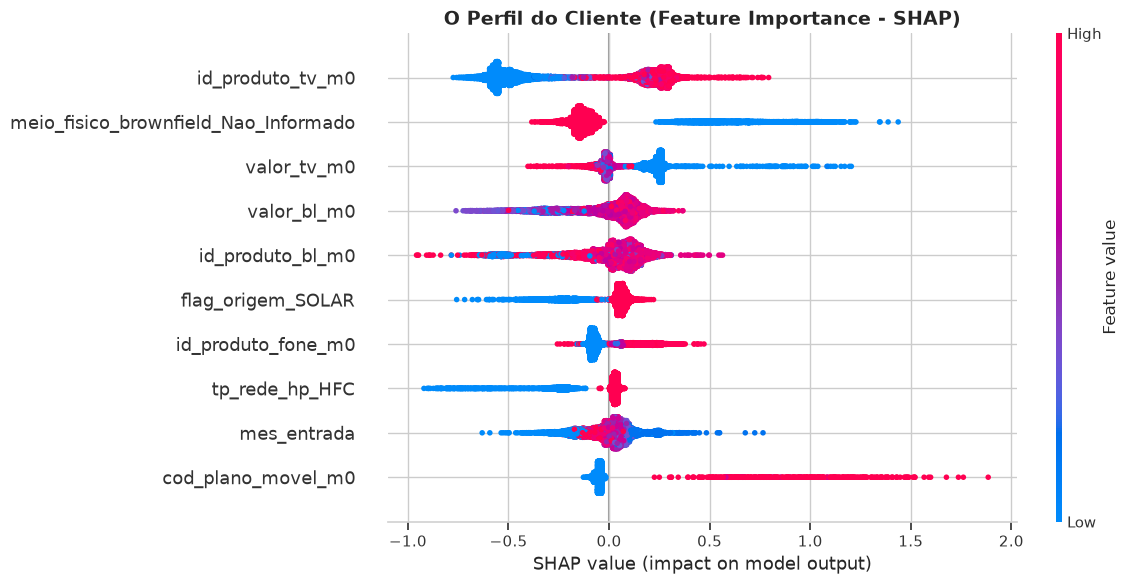

🌟 As 5 variáveis que mais definem o perfil: ['id_produto_tv_m0', 'meio_fisico_brownfield_Nao_Informado', 'valor_tv_m0', 'valor_bl_m0', 'id_produto_bl_m0']


In [15]:
print("🔍 Calculando a importância das variáveis com SHAP...")
# Usamos uma amostra de 10.000 clientes do teste para rodar rápido e não travar a memória
amostra_X = X_test.sample(n=10000, random_state=42)

# Explainer do SHAP otimizado para árvores (XGBoost)
explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer.shap_values(amostra_X)

# Gráfico de Importância (Summary Plot)
plt.figure(figsize=(10, 6))
plt.title("O Perfil do Cliente (Feature Importance - SHAP)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, amostra_X, max_display=10, show=False)

# Ajuste visual padrão Claro
fig = plt.gcf()
fig.set_size_inches(12, 6)
plt.tight_layout()
plt.show()

# Pegando os nomes das top 5 features para o nosso Dashboard depois
top_features = amostra_X.columns[np.argsort(np.abs(shap_values).mean(0))[-5:]][::-1].tolist()
print(f"🌟 As 5 variáveis que mais definem o perfil: {top_features}")

💡 **Insights de Negócio**: O Perfil de Retenção (Explicabilidade SHAP) <br> Baseado na interpretação do modelo preditivo, o comportamento do cliente no funil de retenção não é aleatório. Ele é ditado principalmente pelo pacote atual e pelas limitações de infraestrutura. <br> **O Paradoxo da Sensibilidade a Preço (TV vs. Banda Larga)**: O modelo revelou comportamentos opostos dependendo do produto. Clientes que já pagam um valor alto de TV (valor_tv_m0 em vermelho empurrando para o lado negativo) têm menor propensão a aceitar movimentações. Isso indica uma forte "fadiga de preço" com a TV por assinatura. Em contrapartida, clientes com alto valor em Banda Larga (**valor_bl_m0** em vermelho empurrando para o lado positivo) são mais propensos a realizar movimentações, comprovando que a internet é o produto âncora e os clientes estão dispostos a negociar ou pagar mais por upgrades de velocidade. <br> **A Infraestrutura Limita a Oferta**: A variável **meio_fisico_brownfield_Nao_Informado** tem um impacto altamente negativo. Isso faz total sentido de negócio: se a Claro não tem a informação correta do meio físico (ou se é um meio legado que não permite fibra/altas velocidades), o atendente fica engessado e não consegue oferecer os combos mais atrativos, afundando a chance de retenção com movimentação. <br> **O "Ponto de Partida" dita a regra**: Os IDs específicos dos produtos que o cliente já possui no momento zero (**id_produto_tv_m0** e **id_produto_bl_m0**) são os maiores determinantes da retenção. Isso significa que a estratégia não deve ser focada em descontos genéricos, mas sim em matrizes de transição (ex: se o cliente tem o Plano A, a oferta com maior probabilidade de sucesso é a B). <br> **Validação da IA no Atendimento**: A variável **flag_origem_SOLAR** apareceu no topo impactando positivamente as predições. O SHAP comprova matematicamente a nossa hipótese da Análise Exploratória: a ferramenta de recomendação reduz o atrito e empurra a probabilidade de retenção para cima se comparada ao catálogo legado.

### Gerar um dashboard interativo com as metricas obtidas do modelo

* Estruturar um arquivo json para leitura das metricas obtidas (HTML/JS fará a leitura desse arquivo para geração dos grafos)

In [16]:
import json

# Consolidando as métricas e perfil em um dicionário
resultados_finais = {
    "metricas_producao": {
        "auc_roc": round(auc, 4),
        "ks_stat": round(ks_stat * 100, 2),
        "mcc": round(mcc, 4),
        "cv_auc_medio": round(cv_scores.mean(), 4)
    },
    "matriz_confusao": {
        "verdadeiros_negativos": int(cm[0][0]),
        "falsos_positivos": int(cm[0][1]),
        "falsos_negativos": int(cm[1][0]),
        "verdadeiros_positivos": int(cm[1][1])
    },
    "perfil_cliente_top_features": top_features,
    "insight_principal": "A ferramenta Solar supera o Catálogo Legado com quase 6% a mais de conversão."
}

# Salvando no mesmo diretório
with open('../data/metricas_modelo.json', 'w', encoding='utf-8') as f:
    json.dump(resultados_finais, f, ensure_ascii=False, indent=4)
    
print("JSON exportado com sucesso para '../data/metricas_modelo.json'!")

JSON exportado com sucesso para '../data/metricas_modelo.json'!


In [17]:
import os

# Cria uma pasta para o Dashboard (se não existir)
os.makedirs('../dashboard', exist_ok=True)

# 1. Exportando as Imagens (O Jupyter já tem elas em memória, mas vamos garantir o salvamento)
# Salva a Matriz de Confusão
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Retido', 'Retido'])
disp.plot(cmap='Reds', ax=ax, values_format='d')
plt.title('Matriz de Confusão')
plt.grid(False)
plt.savefig('../dashboard/matriz_confusao.png', bbox_inches='tight')
plt.close()

# Salva o SHAP
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, amostra_X, max_display=10, show=False)
plt.title("O Perfil do Cliente (SHAP)", fontsize=14)
plt.savefig('../dashboard/shap_plot.png', bbox_inches='tight')
plt.close()

# 2. Exportando as Métricas para o JSON
resultados = {
    "metricas": {
        "auc_roc": round(auc, 4),
        "ks_stat": round(ks_stat * 100, 1),
        "mcc": round(mcc, 4),
        "cv_auc_medio": round(cv_scores.mean(), 4)
    },
    "eda": {
        "insight_regional": "SP e MG lideram a retenção (~30%). Sul apresenta o maior risco de churn (23-25%).",
        "insight_solar": "A ferramenta Solar (29.8%) supera drasticamente o Catálogo Legado (24.0%)."
    },
    "top_features": top_features
}

with open('../dashboard/dados_modelo.json', 'w', encoding='utf-8') as f:
    json.dump(resultados, f, ensure_ascii=False, indent=4)

print("✅ Todos os arquivos do Dashboard foram gerados na pasta '../dashboard/'!")

✅ Todos os arquivos do Dashboard foram gerados na pasta '../dashboard/'!
